# MNIST Digit Recognition — Overfitting & Regularization Study

**Project Stages**
1. **Stage 1** — Data Pipeline: load all 70k MNIST images, create fixed train/val/test splits, build DataLoaders
2. **Stage 2** - Baseline Model
3. **Stage 3** — Engineer Overfitting: design an intentionally over-parameterised model and train it until it memorises the training data
4. **Stage 4** — Overcome Overfitting: apply regularisation techniques to the *same* architecture to close the train/val gap

> ⚠️ The train/val/test split is **never** changed across all three stages.

## Cell 1 — Imports & Reproducibility

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Using device    : {device}")


PyTorch version : 2.5.1+cu121
Using device    : cuda


## Stage 1 — Data Pipeline

### Design Decisions
| Split | Size | Source |
|-------|------|--------|
| Train | 50 000 | MNIST train set |
| Validation | 10 000 | MNIST train set |
| Test | 10 000 | MNIST test set (held-out) |

- **Total**: 70 000 images (entire MNIST dataset)
- Split is created **once** with a fixed random seed and never changed.
- Normalisation statistics: mean = 0.1307, std = 0.3081 (full MNIST population values).

In [10]:
# ── Standard transform (no augmentation) ────────────────────────────────────
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# ── Download full MNIST ──────────────────────────────────────────────────────
full_train_dataset = datasets.MNIST(root='./data', train=True,
                                     download=True, transform=base_transform)
test_dataset       = datasets.MNIST(root='./data', train=False,
                                     download=True, transform=base_transform)

# ── Fixed train / val split ──────────────────────────────────────────────────
TRAIN_SIZE = 50_000
VAL_SIZE   = 10_000

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_train_dataset, [TRAIN_SIZE, VAL_SIZE], generator=generator
)

# Store indices so Stage 3 can reuse the exact same split
train_indices = train_dataset.indices
val_indices   = val_dataset.indices

# ── DataLoaders ──────────────────────────────────────────────────────────────
BATCH_SIZE = 256

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples      : {len(train_dataset):>6,}")
print(f"Validation samples : {len(val_dataset):>6,}")
print(f"Test samples       : {len(test_dataset):>6,}")
print(f"Train batches      : {len(train_loader):>6,}")
print(f"Val batches        : {len(val_loader):>6,}")


Train samples      : 50,000
Validation samples : 10,000
Test samples       : 10,000
Train batches      :    196
Val batches        :     40


### Quick sanity check — visualise a batch

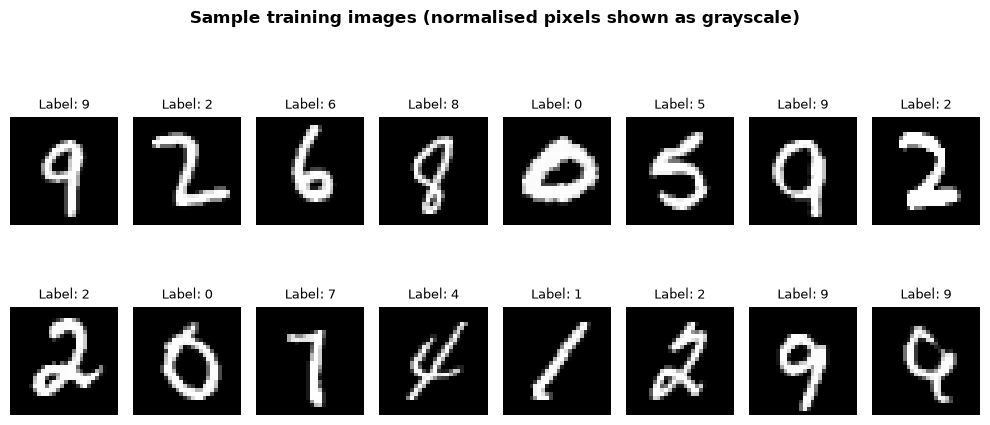

Image tensor shape : torch.Size([64, 1, 28, 28])
Label tensor shape : torch.Size([64])
Pixel range        : [-0.424, 2.821]


In [3]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(10, 5))
fig.suptitle("Sample training images (normalised pixels shown as grayscale)",
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Image tensor shape : {images.shape}")   # (64, 1, 28, 28)
print(f"Label tensor shape : {labels.shape}")   # (64,)
print(f"Pixel range        : [{images.min():.3f}, {images.max():.3f}]")


## Shared Training Utilities

In [21]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Run one full pass over the training set. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct    += (logits.argmax(dim=1) == y).sum().item()
        n          += len(y)
    return total_loss / n, correct / n


def evaluate(model, loader, criterion):
    """Evaluate model on a dataloader. Returns (avg_loss, accuracy)."""
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss   = criterion(logits, y)
            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(dim=1) == y).sum().item()
            n          += len(y)
    return total_loss / n, correct / n


def run_training(model, train_loader, val_loader, optimizer, criterion,
                 epochs=30, label=""):
    """Full training loop. Returns history dict."""
    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | "
          f"{'Val Loss':>9} | {'Val Acc':>8}")
    print("-" * 58)
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | "
        f"{va_loss:>9.4f} | {va_acc:>8.4f}")
    return history


def plot_history(histories: dict, title: str):
    """
    histories = {label: history_dict, ...}
    Plots loss and accuracy curves side-by-side.
    """
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, (label, hist) in enumerate(histories.items()):
        c = colors[i % len(colors)]
        ep = range(1, len(hist['train_loss']) + 1)

        axes[0].plot(ep, hist['train_loss'], color=c, linestyle='-',
                     linewidth=2, label=f"{label} – Train")
        axes[0].plot(ep, hist['val_loss'],   color=c, linestyle='--',
                     linewidth=2, label=f"{label} – Val")

        axes[1].plot(ep, hist['train_acc'], color=c, linestyle='-',
                     linewidth=2, label=f"{label} – Train")
        axes[1].plot(ep, hist['val_acc'],   color=c, linestyle='--',
                     linewidth=2, label=f"{label} – Val")

    for ax, ylabel, ylbl in zip(axes,
                                 ['Loss', 'Accuracy'],
                                 ['Cross-Entropy Loss', 'Accuracy']):
        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel(ylbl, fontsize=11)
        ax.set_title(ylabel, fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("Utility functions defined ✓")


Utility functions defined ✓


## Stage 2 — Baseline Model

### Strategy
The baseline model serves as a **reference architecture** to establish normal learning behaviour before intentionally inducing overfitting.

| Choice | Value | Effect |
|----------|----------|----------|
| Hidden layers | 128 → 64 | Sufficient capacity for MNIST without excessive complexity |
| Activation | ReLU | Introduces non-linearity and enables efficient gradient propagation |
| Optimiser | Adam, lr = 5e-4 | Fast and stable convergence |
| Weight decay | 0 | Pure baseline without regularisation |
| Data augmentation | None | Allows evaluation of natural model generalisation |
| Epochs | 30 | Enough training to reach convergence without prolonged fitting |

**Expected training signal**: both training and validation losses decrease steadily, training and validation accuracies remain close, and only a small generalisation gap appears — indicating effective learning with minimal overfitting.

In [ ]:
class BaselineNet(nn.Module):
    """
    Baseline (Normal) model — Stage 2.
    A compact fully connected network with light Dropout regularization,
    representing a properly sized, well-regularized reference architecture
    before capacity is scaled up in Stage 3 to induce overfitting.
    """
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)


model_baseline = BaselineNet().to(device)
total_params = sum(p.numel() for p in model_baseline.parameters())
print(f"Architecture : BaselineNet (Normal Model)")
print(f"Parameters   : {total_params:,}")
print()
print(model_baseline)

Architecture : BaselineNet (Normal Model)
Parameters   : 101,770

BaselineNet(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
EPOCHS = 30
criterion = nn.CrossEntropyLoss()

optimizer_baseline = optim.Adam(model_baseline.parameters(), lr=5e-4)

print("=" * 60)
print("Stage 2 — Training BaselineNet (Normal Model)")
print("=" * 60)
history_baseline = run_training(
    model_baseline, train_loader, val_loader,
    optimizer_baseline, criterion,
    epochs=EPOCHS, label="BaselineNet"         
)

Stage 2 — Training BaselineNet (Normal Model)
 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc
----------------------------------------------------------
     1 |     0.5519 |    0.8448 |    0.2921 |   0.9132
     2 |     0.2633 |    0.9234 |    0.2188 |   0.9378
     3 |     0.2053 |    0.9411 |    0.1801 |   0.9470
     4 |     0.1721 |    0.9509 |    0.1566 |   0.9542
     5 |     0.1475 |    0.9569 |    0.1435 |   0.9580
     6 |     0.1286 |    0.9625 |    0.1295 |   0.9600
     7 |     0.1149 |    0.9663 |    0.1176 |   0.9639
     8 |     0.1049 |    0.9692 |    0.1131 |   0.9654
     9 |     0.0956 |    0.9720 |    0.1067 |   0.9681
    10 |     0.0862 |    0.9743 |    0.1007 |   0.9691
    11 |     0.0792 |    0.9761 |    0.0945 |   0.9709
    12 |     0.0746 |    0.9782 |    0.0929 |   0.9715
    13 |     0.0683 |    0.9796 |    0.0900 |   0.9717
    14 |     0.0634 |    0.9810 |    0.0874 |   0.9720
    15 |     0.0612 |    0.9821 |    0.0849 |   0.9743
    16 |     0.

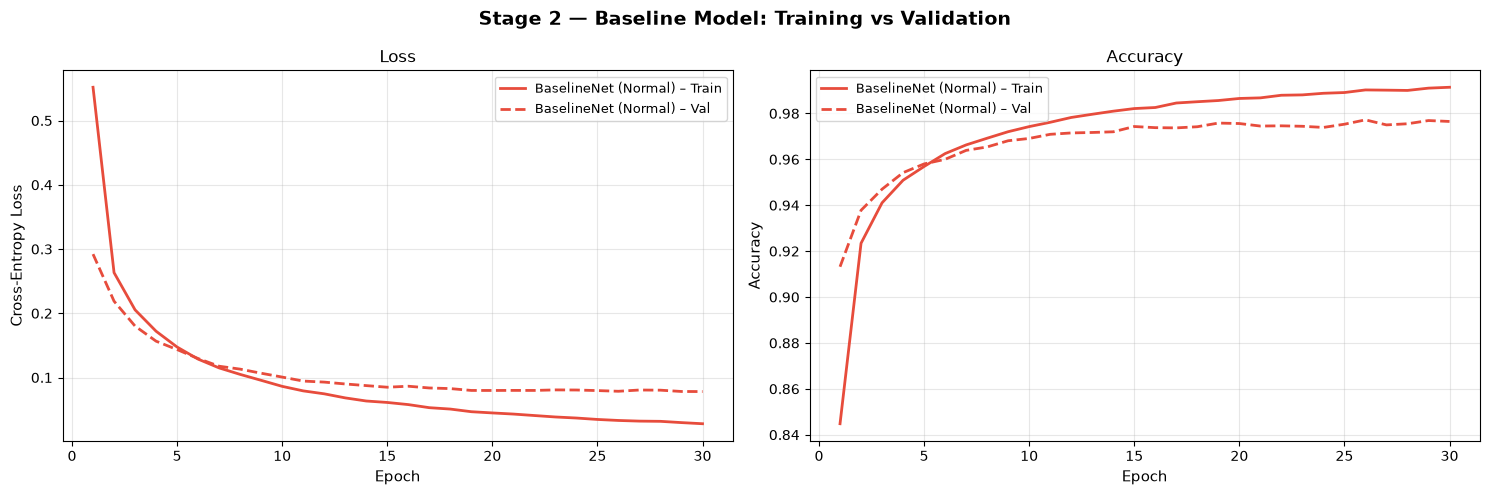

Final Train Loss     : 0.0280
Final Val   Loss      : 0.0781
Loss Ratio (Val/Train): 2.79
Final Train Accuracy  : 0.9914
Final Val   Accuracy  : 0.9765
Generalisation Gap    : 0.0149


In [ ]:
plot_history(
    {"BaselineNet (Normal)": history_baseline},
    title="Stage 2 — Baseline Model: Training vs Validation"
)

final_train_acc = history_baseline['train_acc'][-1]
final_val_acc   = history_baseline['val_acc'][-1]
final_train_loss = history_baseline['train_loss'][-1]
final_val_loss   = history_baseline['val_loss'][-1]
gap = final_train_acc - final_val_acc
loss_ratio = final_val_loss / final_train_loss

print(f"Final Train Loss     : {final_train_loss:.4f}")
print(f"Final Val   Loss      : {final_val_loss:.4f}")
print(f"Loss Ratio (Val/Train): {loss_ratio:.2f}")
print(f"Final Train Accuracy  : {final_train_acc:.4f}")
print(f"Final Val   Accuracy  : {final_val_acc:.4f}")
print(f"Generalisation Gap    : {gap:.4f}")

## Stage 3 — Engineer Overfitting

### Strategy
To deliberately overfit we make the model **massively over-parameterised** relative to the dataset:

| Choice | Value | Effect |
|--------|-------|--------|
| Hidden layers | 4 × 2048 + 1 × 1024 | ~25 M parameters for only 50 k samples |
| Activation | ReLU (no Dropout) | No stochastic regularisation |
| Optimiser | Adam, lr = 1e-3 | Fast convergence → quick memorisation |
| Weight decay | 0 | No L2 penalty |
| Data augmentation | None | Model sees identical images every epoch |

**Expected training signal**: train loss → ~0, train accuracy → ~99 %+, while validation loss *rises* and val accuracy stagnates — the classic overfitting signature.

In [22]:
class OverfitNet(nn.Module):
    """
    Intentionally over-parameterised fully-connected network.
    ~25 M parameters — designed to memorise the training set.
    Architecture is IDENTICAL in Stage 4; only training procedure changes.
    """
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),                          # 28*28 = 784

            nn.Linear(784,  2048), nn.ReLU(),
            nn.Linear(2048, 2048), nn.ReLU(),
            nn.Linear(2048, 2048), nn.ReLU(),
            nn.Linear(2048, 2048), nn.ReLU(),
            nn.Linear(2048, 1024), nn.ReLU(),

            nn.Linear(1024, 10)                   # 10 digit classes
        )

    def forward(self, x):
        return self.network(x)


model_overfit = OverfitNet().to(device)

total_params = sum(p.numel() for p in model_overfit.parameters())
print(f"Architecture : OverfitNet")
print(f"Parameters   : {total_params:,}")
print()
print(model_overfit)


Architecture : OverfitNet
Parameters   : 16,305,162

OverfitNet(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=2048, bias=True)
    (2): ReLU()
    (3): Linear(in_features=2048, out_features=2048, bias=True)
    (4): ReLU()
    (5): Linear(in_features=2048, out_features=2048, bias=True)
    (6): ReLU()
    (7): Linear(in_features=2048, out_features=2048, bias=True)
    (8): ReLU()
    (9): Linear(in_features=2048, out_features=1024, bias=True)
    (10): ReLU()
    (11): Linear(in_features=1024, out_features=10, bias=True)
  )
)


### Train the Overfitting Model

In [23]:
EPOCHS    = 50
criterion = nn.CrossEntropyLoss()

optimizer_overfit = optim.Adam(
    model_overfit.parameters(),
    lr=1e-3,
    weight_decay=0.0      # ← no regularisation
)

print("=" * 60)
print("Stage 3 — Training OverfitNet (no regularisation)")
print("=" * 60)
history_overfit = run_training(
    model_overfit, train_loader, val_loader,
    optimizer_overfit, criterion,
    epochs=EPOCHS, label="OverfitNet"
)


Stage 3 — Training OverfitNet (no regularisation)
 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc
----------------------------------------------------------
     1 |     0.3262 |    0.8963 |    0.1516 |   0.9601
     2 |     0.1192 |    0.9668 |    0.1400 |   0.9641
     3 |     0.0826 |    0.9775 |    0.1075 |   0.9714
     4 |     0.0639 |    0.9820 |    0.1341 |   0.9709
     5 |     0.0566 |    0.9839 |    0.1095 |   0.9771
     6 |     0.0558 |    0.9849 |    0.1227 |   0.9720
     7 |     0.0466 |    0.9879 |    0.1134 |   0.9749
     8 |     0.0412 |    0.9891 |    0.1390 |   0.9748
     9 |     0.0347 |    0.9909 |    0.1250 |   0.9768
    10 |     0.0361 |    0.9907 |    0.1408 |   0.9754
    11 |     0.0358 |    0.9905 |    0.1344 |   0.9772
    12 |     0.0297 |    0.9923 |    0.1932 |   0.9643
    13 |     0.0325 |    0.9921 |    0.1027 |   0.9788
    14 |     0.0259 |    0.9929 |    0.1420 |   0.9743
    15 |     0.0275 |    0.9930 |    0.1435 |   0.9784
    16 |   

### Visualise Overfitting

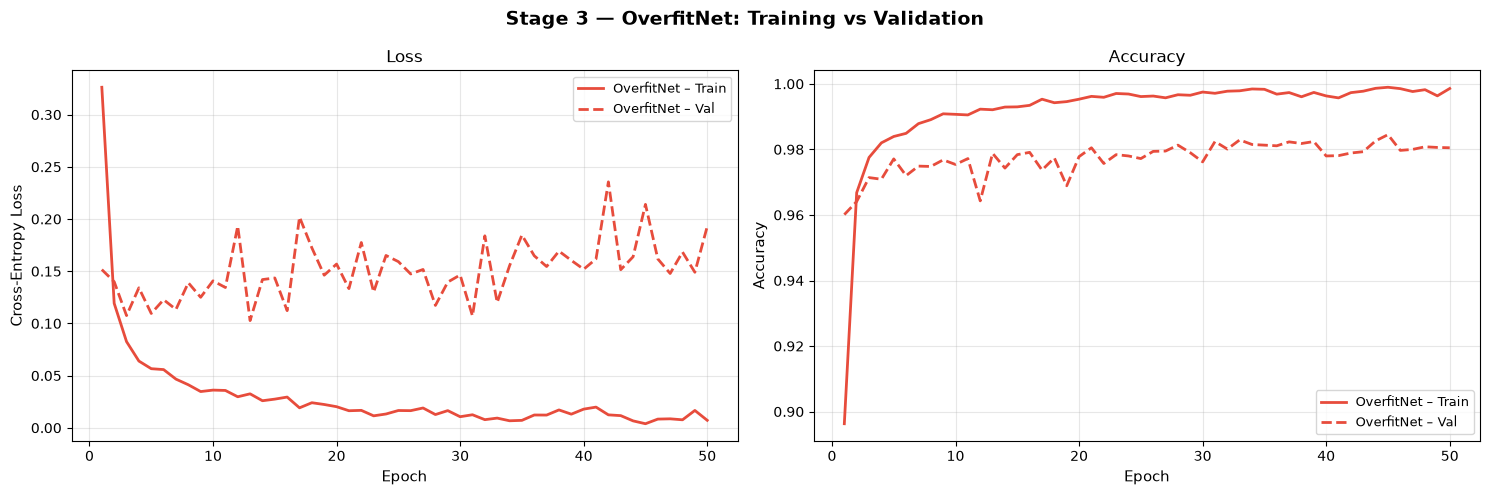

Final Train Accuracy : 0.9986 (99.86%)
Final Val   Accuracy : 0.9805  (98.05%)
Generalisation Gap   : 0.0181  (1.81 pp)

✅ Overfitting confirmed


In [24]:
plot_history(
    {"OverfitNet": history_overfit},
    title="Stage 3 — OverfitNet: Training vs Validation"
)

# Gap analysis
final_train_acc = history_overfit['train_acc'][-1]
final_val_acc   = history_overfit['val_acc'][-1]
gap             = final_train_acc - final_val_acc

print(f"Final Train Accuracy : {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"Final Val   Accuracy : {final_val_acc:.4f}  ({final_val_acc*100:.2f}%)")
print(f"Generalisation Gap   : {gap:.4f}  ({gap*100:.2f} pp)")
print()
if gap > 0.01:
    print("✅ Overfitting confirmed")
else:
    print("⚠️  Gap is small — consider training more epochs or increasing model size.")


## Stage 4 — Overcome Overfitting (Same Architecture)

### Allowed changes (no architecture modification)
The `OverfitNet` class definition is **unchanged**. We fix overfitting purely through:

| Technique | Implementation | Why it helps |
|-----------|---------------|--------------|
| **L2 Regularisation** | `weight_decay=1e-4` in Adam | Penalises large weights, discourages memorisation |
| **Data Augmentation** | Random rotation ±10°, Random translation ±10% | Each epoch the model sees a slightly different version of each image — effective dataset size increases |
| **Lower learning rate** | `lr = 5e-4` | More stable convergence, less overshoot into sharp minima |

> The train/val/test **split indices are identical** — we reuse `train_indices` from Stage 1.

In [25]:
# ── Augmented transform for Stage 4 train set ────────────────────────────────
augmented_transform = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Reload training images with augmentation, keep EXACT same indices
full_train_aug = datasets.MNIST(root='./data', train=True,
                                 download=False, transform=augmented_transform)
train_dataset_aug   = Subset(full_train_aug, train_indices)   # same 50k indices
train_loader_aug    = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE,
                                  shuffle=True, num_workers=2, pin_memory=True)

# Val and test loaders are UNCHANGED (no augmentation on evaluation sets)
print(f"Augmented train loader : {len(train_loader_aug)} batches of {BATCH_SIZE}")
print(f"Val loader             : {len(val_loader)} batches  (unchanged)")
print(f"Test loader            : {len(test_loader)} batches  (unchanged)")


Augmented train loader : 196 batches of 256
Val loader             : 40 batches  (unchanged)
Test loader            : 40 batches  (unchanged)


In [26]:
# ── Same architecture, new training procedure ─────────────────────────────────
model_fixed = OverfitNet().to(device)      # identical class — no change

optimizer_fixed = optim.Adam(
    model_fixed.parameters(),
    lr=5e-4,            # ← lower learning rate
    weight_decay=1e-4   # ← L2 regularisation
)

print("=" * 60)
print("Stage 4 — Training OverfitNet WITH regularisation")
print("=" * 60)
history_fixed = run_training(
    model_fixed, train_loader_aug, val_loader,
    optimizer_fixed, criterion,
    epochs=EPOCHS, label="FixedNet"
)


Stage 4 — Training OverfitNet WITH regularisation
 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc
----------------------------------------------------------
     1 |     0.5756 |    0.8096 |    0.1573 |   0.9564
     2 |     0.1988 |    0.9393 |    0.1105 |   0.9666
     3 |     0.1628 |    0.9512 |    0.1003 |   0.9715
     4 |     0.1386 |    0.9578 |    0.0950 |   0.9713
     5 |     0.1295 |    0.9615 |    0.0785 |   0.9754
     6 |     0.1180 |    0.9645 |    0.0834 |   0.9759
     7 |     0.1074 |    0.9675 |    0.0751 |   0.9780
     8 |     0.1053 |    0.9675 |    0.0818 |   0.9741
     9 |     0.0983 |    0.9699 |    0.0684 |   0.9799
    10 |     0.0927 |    0.9720 |    0.0673 |   0.9802
    11 |     0.0910 |    0.9721 |    0.0646 |   0.9806
    12 |     0.0853 |    0.9739 |    0.0777 |   0.9793
    13 |     0.0822 |    0.9740 |    0.0667 |   0.9812
    14 |     0.0800 |    0.9756 |    0.0543 |   0.9845
    15 |     0.0775 |    0.9761 |    0.0536 |   0.9834
    16 |   

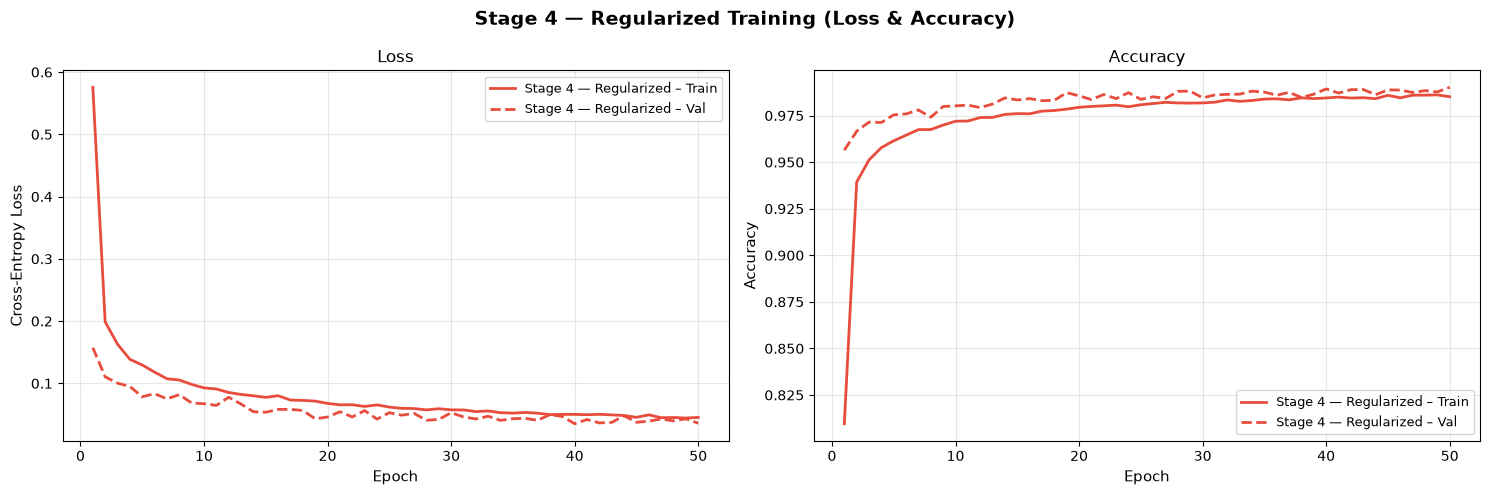

In [27]:
plot_history(
    {"Stage 4 — Regularized": history_fixed},
    title="Stage 4 — Regularized Training (Loss & Accuracy)"
)

## Comparison — Stage 3 vs Stage 4

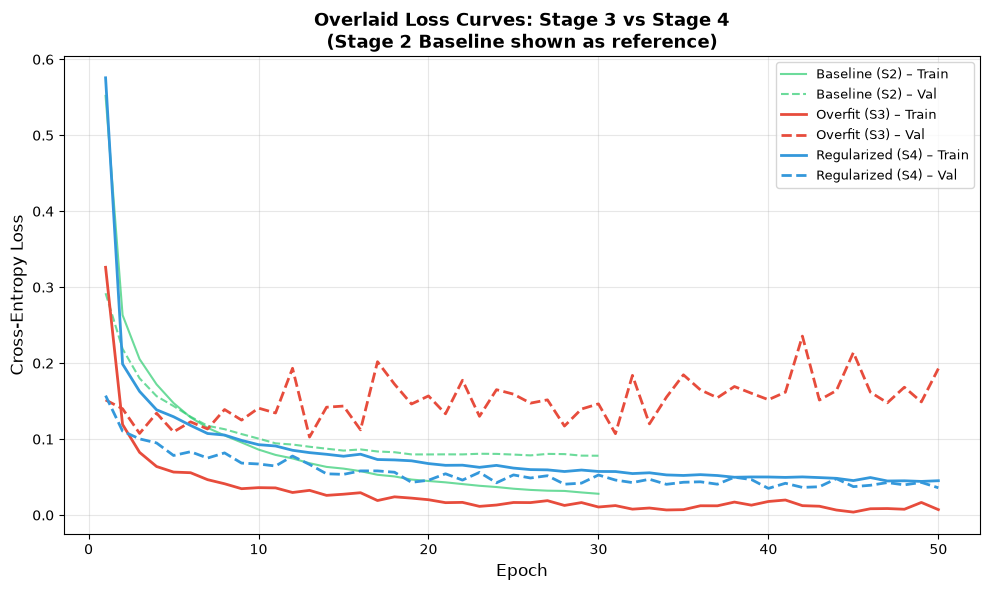

Saved: fig5_loss_comparison.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'baseline': '#2ecc71', 'overfit': '#e74c3c', 'fixed': '#3498db'}

# ── Stage 2 — Baseline (reference, dotted) ────────────────────────────────
ep_base = range(1, len(history_baseline['train_loss']) + 1)
ax.plot(ep_base, history_baseline['train_loss'], color=colors['baseline'],
         linestyle='-', linewidth=1.5, alpha=0.7, label='Baseline (S2) – Train')
ax.plot(ep_base, history_baseline['val_loss'], color=colors['baseline'],
         linestyle='--', linewidth=1.5, alpha=0.7, label='Baseline (S2) – Val')

# ── Stage 3 — Overfit ──────────────────────────────────────────────────────
ep_full = range(1, len(history_overfit['train_loss']) + 1)
ax.plot(ep_full, history_overfit['train_loss'], color=colors['overfit'],
         linestyle='-', linewidth=2, label='Overfit (S3) – Train')
ax.plot(ep_full, history_overfit['val_loss'], color=colors['overfit'],
         linestyle='--', linewidth=2, label='Overfit (S3) – Val')

# ── Stage 4 — Regularized ─────────────────────────────────────────────────
ax.plot(ep_full, history_fixed['train_loss'], color=colors['fixed'],
         linestyle='-', linewidth=2, label='Regularized (S4) – Train')
ax.plot(ep_full, history_fixed['val_loss'], color=colors['fixed'],
         linestyle='--', linewidth=2, label='Regularized (S4) – Val')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Overlaid Loss Curves: Stage 3 vs Stage 4\n(Stage 2 Baseline shown as reference)',
              fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right', ncol=1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig5_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig5_loss_comparison.png")

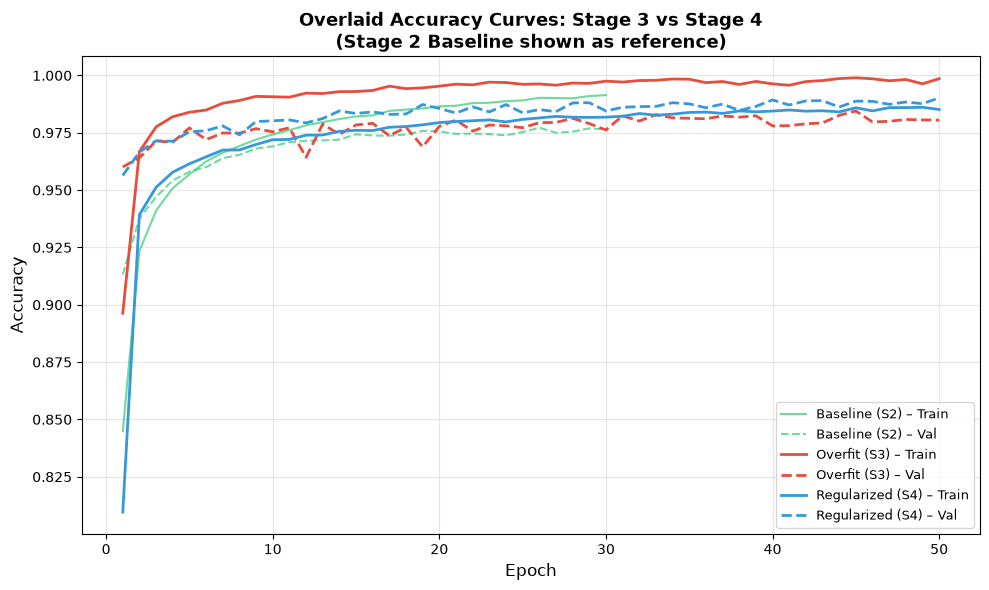

Saved: fig6_accuracy_comparison.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# ── Stage 2 — Baseline (reference) ────────────────────────────────────────
ax.plot(ep_base, history_baseline['train_acc'], color=colors['baseline'],
         linestyle='-', linewidth=1.5, alpha=0.7, label='Baseline (S2) – Train')
ax.plot(ep_base, history_baseline['val_acc'], color=colors['baseline'],
         linestyle='--', linewidth=1.5, alpha=0.7, label='Baseline (S2) – Val')

# ── Stage 3 — Overfit ──────────────────────────────────────────────────────
ax.plot(ep_full, history_overfit['train_acc'], color=colors['overfit'],
         linestyle='-', linewidth=2, label='Overfit (S3) – Train')
ax.plot(ep_full, history_overfit['val_acc'], color=colors['overfit'],
         linestyle='--', linewidth=2, label='Overfit (S3) – Val')

# ── Stage 4 — Regularized ─────────────────────────────────────────────────
ax.plot(ep_full, history_fixed['train_acc'], color=colors['fixed'],
         linestyle='-', linewidth=2, label='Regularized (S4) – Train')
ax.plot(ep_full, history_fixed['val_acc'], color=colors['fixed'],
         linestyle='--', linewidth=2, label='Regularized (S4) – Val')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Overlaid Accuracy Curves: Stage 3 vs Stage 4\n(Stage 2 Baseline shown as reference)',
              fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right', ncol=1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig6_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig6_accuracy_comparison.png")

### Loss curves — closer look

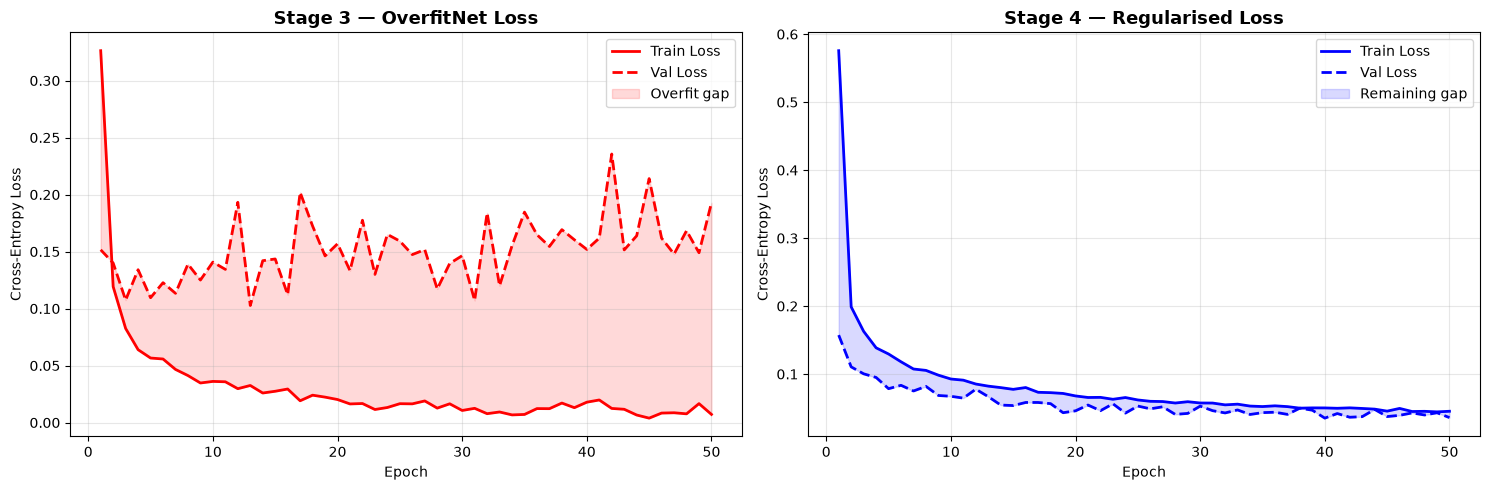

Saved: loss_curves.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ep = range(1, EPOCHS + 1)

# Stage 2
axes[0].plot(ep, history_overfit['train_loss'], 'r-',  lw=2, label='Train Loss')
axes[0].plot(ep, history_overfit['val_loss'],   'r--', lw=2, label='Val Loss')
axes[0].fill_between(ep,
    history_overfit['train_loss'], history_overfit['val_loss'],
    alpha=0.15, color='red', label='Overfit gap')
axes[0].set_title('Stage 3 — OverfitNet Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Stage 3
axes[1].plot(ep, history_fixed['train_loss'], 'b-',  lw=2, label='Train Loss')
axes[1].plot(ep, history_fixed['val_loss'],   'b--', lw=2, label='Val Loss')
axes[1].fill_between(ep,
    history_fixed['train_loss'], history_fixed['val_loss'],
    alpha=0.15, color='blue', label='Remaining gap')
axes[1].set_title('Stage 4 — Regularised Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_curves.png")


## Final Evaluation on Held-Out Test Set

The test set has **never** been seen during training or hyperparameter selection.

In [30]:
_, overfit_test_acc = evaluate(model_overfit, test_loader, criterion)
_, fixed_test_acc   = evaluate(model_fixed,   test_loader, criterion)
_, baseline_test_acc = evaluate(model_baseline, test_loader, criterion)
print(f"Baseline Model Test Accuracy: {baseline_test_acc:.4f}")
print("=" * 45)
print(f"{'Model':<25} {'Test Accuracy':>15}")
print("-" * 45)
print(f"{'Stage 2 — Baseline':<25} {baseline_test_acc:>14.4f}")
print(f"{'Stage 3 — OverfitNet':<25} {overfit_test_acc:>14.4f}")
print(f"{'Stage 4 — Regularised':<25} {fixed_test_acc:>14.4f}")
print("=" * 45)
improvement = (fixed_test_acc - overfit_test_acc) * 100
print(f"\nRegularisation improved test accuracy by {improvement:.2f} percentage points.")


Baseline Model Test Accuracy: 0.9790
Model                       Test Accuracy
---------------------------------------------
Stage 2 — Baseline                0.9790
Stage 3 — OverfitNet              0.9832
Stage 4 — Regularised             0.9904

Regularisation improved test accuracy by 0.72 percentage points.


### Per-Class Accuracy (Stage 4 — Regularised Model)

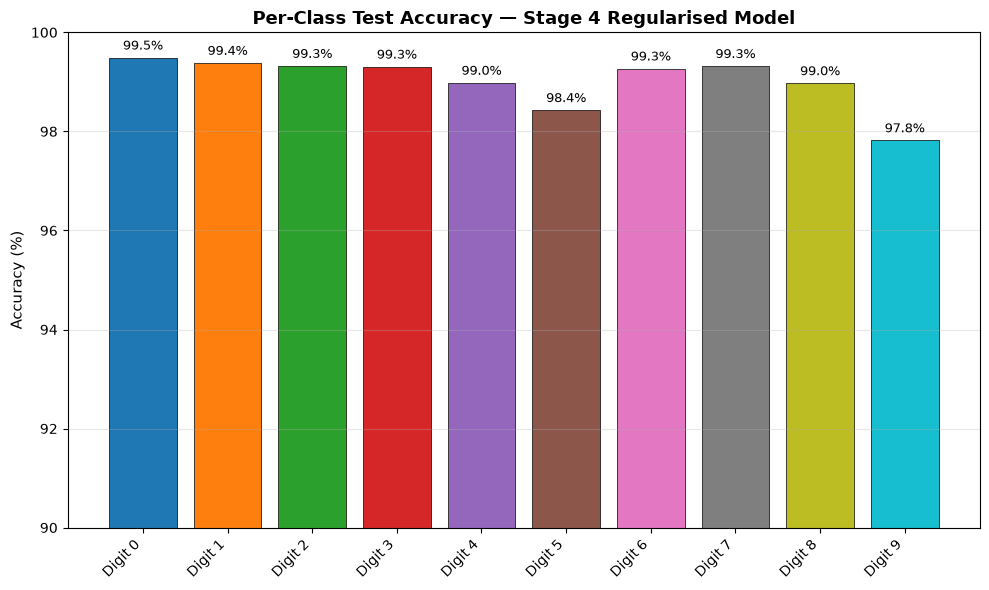


Per-class breakdown:
  Digit 0:  99.49%  █████████████████████████████████████████████████
  Digit 1:  99.38%  █████████████████████████████████████████████████
  Digit 2:  99.32%  █████████████████████████████████████████████████
  Digit 3:  99.31%  █████████████████████████████████████████████████
  Digit 4:  98.98%  █████████████████████████████████████████████████
  Digit 5:  98.43%  █████████████████████████████████████████████████
  Digit 6:  99.27%  █████████████████████████████████████████████████
  Digit 7:  99.32%  █████████████████████████████████████████████████
  Digit 8:  98.97%  █████████████████████████████████████████████████
  Digit 9:  97.82%  ████████████████████████████████████████████████


In [32]:
class_correct = torch.zeros(10)
class_total   = torch.zeros(10)

model_fixed.eval()
with torch.no_grad():
    for X, y in test_loader:
        X, y   = X.to(device), y.to(device)
        logits = model_fixed(X)
        preds  = logits.argmax(dim=1)
        for cls in range(10):
            mask = (y == cls)
            class_correct[cls] += (preds[mask] == y[mask]).sum().item()
            class_total[cls]   += mask.sum().item()

per_class_acc = (class_correct / class_total).numpy()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(10), per_class_acc * 100,
              color=plt.cm.tab10(np.linspace(0, 1, 10)), edgecolor='black', linewidth=0.5)
ax.set_xticks(range(10))
ax.set_xticklabels([f"Digit {i}" for i in range(10)], rotation=45, ha='right')
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Test Accuracy — Stage 4 Regularised Model', fontsize=13, fontweight='bold')
ax.set_ylim(90, 100)
ax.grid(True, axis='y', alpha=0.3)

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-class breakdown:")
for i, acc in enumerate(per_class_acc):
    bar = '█' * int(acc * 50)
    print(f"  Digit {i}: {acc*100:6.2f}%  {bar}")


### Confusion Matrix ###


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x0000021BD86182C0>
Traceback (most recent call last):
  File "c:\mnstproj\mnist_env\Lib\site-packages\torch\utils\data\dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "c:\mnstproj\mnist_env\Lib\site-packages\torch\utils\data\dataloader.py", line 1562, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


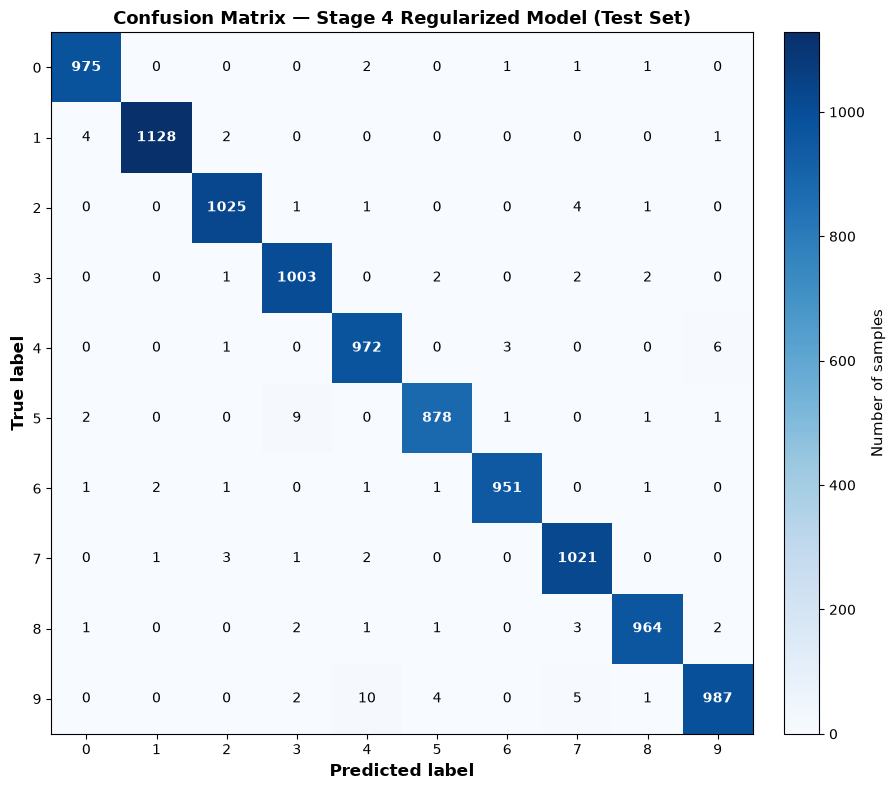

Top 5 most confused digit pairs (excluding correct predictions):

  True: 9  →  Predicted: 4   (10 times)
  True: 5  →  Predicted: 3   (9 times)
  True: 4  →  Predicted: 9   (6 times)
  True: 9  →  Predicted: 7   (5 times)
  True: 9  →  Predicted: 5   (4 times)


In [33]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# ── Collect all predictions and true labels on the test set ─────────────────
model_fixed.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        logits = model_fixed(X)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Compute confusion matrix ─────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap='Blues')

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Number of samples', fontsize=11)

# Ticks and labels
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10))
ax.set_yticklabels(range(10))
ax.set_xlabel('Predicted label', fontsize=12, fontweight='bold')
ax.set_ylabel('True label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix — Stage 4 Regularized Model (Test Set)',
              fontsize=13, fontweight='bold')

# Annotate each cell with its count
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > thresh else "black"
        weight = "bold" if i == j else "normal"
        ax.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color=color, fontsize=10, fontweight=weight)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print most confused digit pairs ──────────────────────────────────────────
print("Top 5 most confused digit pairs (excluding correct predictions):\n")
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

pairs = []
for i in range(10):
    for j in range(10):
        if i != j and cm_no_diag[i, j] > 0:
            pairs.append((cm_no_diag[i, j], i, j))

pairs.sort(reverse=True)
for count, true_digit, pred_digit in pairs[:5]:
    print(f"  True: {true_digit}  →  Predicted: {pred_digit}   ({count} times)")